# MA/V Test-Set Validation

Validate the tuned statistical-arbitrage strategy on data from 2020-01-01 onward, with optional regime filters and trade-noise controls.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


In [21]:
LOOKBACK = 49
ENTRY_Z = 1.5
EXIT_Z = 1.1
E_STOP = 3.9
TEST_START = "2020-01-01"

# Regime filter settings. Thresholds are calibrated on pre-2020 training data only.
REGIME_LOOKBACK = 126
BETA_STABILITY_LOOKBACK = 20
MIN_CORR_QUANTILE = 0.75
MAX_BETA_CHANGE_QUANTILE = 0.90
MAX_SPREAD_SIGMA_QUANTILE = 0.90

USE_CORRELATION_FILTER = True
USE_BETA_STABILITY_FILTER = True
USE_SPREAD_VOL_FILTER = True
EXIT_ON_REGIME_BREAK = False

# Trade-noise controls.
ENTRY_CONFIRM_DAYS = 1
MIN_HOLD_DAYS = 3
COOLDOWN_DAYS = 1


In [22]:
def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)

    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])

    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()

    return df


In [23]:
# Load and merge MA/V prices
v = load_yfinance_csv("../V_daily.csv", "V")
ma = load_yfinance_csv("../MA_daily.csv", "MA")

df = pd.merge(v, ma, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

# Compute returns and log prices
df["V"] = pd.to_numeric(df["V"], errors="coerce")
df["MA"] = pd.to_numeric(df["MA"], errors="coerce")

df = df.dropna(subset=["V", "MA"])
df = df[(df["V"] > 0) & (df["MA"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["V_ret"] = df["V"].pct_change()
df["MA_ret"] = df["MA"].pct_change()

df["log_V"] = np.log(df["V"])
df["log_MA"] = np.log(df["MA"])

training_set = df[(df["Date"] >= "2000-01-01") & (df["Date"] < TEST_START)].copy().reset_index(drop=True)
test_set = df[df["Date"] >= TEST_START].copy().reset_index(drop=True)

test_set[["Date", "V", "MA", "V_ret", "MA_ret"]].head()


,Date,V,MA,V_ret,MA_ret
0,2020-01-02,191.119995,303.390015,0.017137,0.016076
1,2020-01-03,189.600006,300.429993,-0.007953,-0.009756
2,2020-01-06,189.190002,301.230011,-0.002162,0.002663
3,2020-01-07,188.690002,300.209991,-0.002643,-0.003386
4,2020-01-08,191.919998,305.100006,0.017118,0.016289


In [24]:
def add_signal_features(price_df, lookback, regime_lookback, beta_stability_lookback):
    features = price_df.copy().reset_index(drop=True)

    features["beta"] = np.nan
    features["spread"] = np.nan
    features["spread_sigma"] = np.nan
    features["zscore"] = np.nan

    for i in range(lookback, len(features)):
        train = features.iloc[i - lookback:i]

        x = train["log_V"].values
        y = train["log_MA"].values

        beta = np.polyfit(x, y, 1)[0]
        features.loc[i, "beta"] = beta

        train_spread = train["log_MA"] - beta * train["log_V"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = features.loc[i, "log_MA"] - beta * features.loc[i, "log_V"]

        features.loc[i, "spread"] = current_spread
        features.loc[i, "spread_sigma"] = sigma
        features.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    features["return_corr"] = features["V_ret"].rolling(regime_lookback).corr(features["MA_ret"])
    features["beta_change"] = features["beta"].diff().abs()
    features["beta_change_avg"] = features["beta_change"].rolling(beta_stability_lookback).mean()

    return features


def calibrate_regime_thresholds(feature_df):
    training_features = feature_df[(feature_df["Date"] >= "2000-01-01") & (feature_df["Date"] < TEST_START)].copy()

    return {
        "min_corr": training_features["return_corr"].quantile(MIN_CORR_QUANTILE),
        "max_beta_change": training_features["beta_change_avg"].quantile(MAX_BETA_CHANGE_QUANTILE),
        "max_spread_sigma": training_features["spread_sigma"].quantile(MAX_SPREAD_SIGMA_QUANTILE),
    }


In [25]:
def run_strategy(
    feature_df,
    label,
    evaluate_from,
    lookback,
    entry_z,
    exit_z,
    e_stop,
    regime_thresholds=None,
    use_correlation_filter=False,
    use_beta_stability_filter=False,
    use_spread_vol_filter=False,
    exit_on_regime_break=False,
    entry_confirm_days=1,
    min_hold_days=0,
    cooldown_days=0,
):
    result = feature_df.copy().reset_index(drop=True)

    result["corr_ok"] = True
    result["beta_stable"] = True
    result["spread_vol_ok"] = True

    if regime_thresholds is not None:
        if use_correlation_filter:
            result["corr_ok"] = result["return_corr"] >= regime_thresholds["min_corr"]
        if use_beta_stability_filter:
            result["beta_stable"] = result["beta_change_avg"] <= regime_thresholds["max_beta_change"]
        if use_spread_vol_filter:
            result["spread_vol_ok"] = result["spread_sigma"] <= regime_thresholds["max_spread_sigma"]

    result["regime_ok"] = result[["corr_ok", "beta_stable", "spread_vol_ok"]].all(axis=1)
    result["position"] = 0.0

    start_idx = int(result.index[result["Date"] >= evaluate_from][0])
    current_pos = 0
    entry_idx = None
    cooldown_remaining = 0

    for i in range(start_idx, len(result)):
        z = result.loc[i, "zscore"]
        regime_ok = bool(result.loc[i, "regime_ok"])

        if pd.isna(z):
            result.loc[i, "position"] = current_pos
            continue

        if current_pos == 0:
            if cooldown_remaining > 0:
                cooldown_remaining -= 1
            elif regime_ok:
                confirm_start = max(start_idx, i - entry_confirm_days + 1)
                confirm_window = result.loc[confirm_start:i]
                has_confirmation = len(confirm_window) >= entry_confirm_days and confirm_window["regime_ok"].all()

                if has_confirmation and (confirm_window["zscore"] > entry_z).all():
                    current_pos = -1  # short spread: short MA, long V
                    entry_idx = i
                elif has_confirmation and (confirm_window["zscore"] < -entry_z).all():
                    current_pos = 1  # long spread: long MA, short V
                    entry_idx = i

        elif current_pos == 1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            emergency_exit = z < -e_stop
            regime_exit = exit_on_regime_break and not regime_ok
            normal_exit = holding_days >= min_hold_days and z > -exit_z

            if emergency_exit or regime_exit or normal_exit:
                current_pos = 0
                entry_idx = None
                cooldown_remaining = cooldown_days

        elif current_pos == -1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            emergency_exit = z > e_stop
            regime_exit = exit_on_regime_break and not regime_ok
            normal_exit = holding_days >= min_hold_days and z < exit_z

            if emergency_exit or regime_exit or normal_exit:
                current_pos = 0
                entry_idx = None
                cooldown_remaining = cooldown_days

        result.loc[i, "position"] = current_pos

    result["beta_ffill"] = result["beta"].ffill()
    result["spread_ret"] = result["MA_ret"] - result["beta_ffill"] * result["V_ret"]

    result["position_lag"] = result["position"].shift(1).fillna(0)
    result["strategy_ret"] = result["position_lag"] * result["spread_ret"]
    result["strategy_ret"] = result["strategy_ret"].fillna(0)

    result = result.loc[start_idx:].copy().reset_index(drop=True)
    result["equity_curve"] = (1 + result["strategy_ret"]).cumprod()
    result["drawdown"] = result["equity_curve"] / result["equity_curve"].cummax() - 1

    mean_ret = result["strategy_ret"].mean()
    std_ret = result["strategy_ret"].std()
    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret

    return {
        "label": label,
        "lookback": lookback,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "e_stop": e_stop,
        "entry_confirm_days": entry_confirm_days,
        "min_hold_days": min_hold_days,
        "cooldown_days": cooldown_days,
        "start_date": result["Date"].min(),
        "end_date": result["Date"].max(),
        "sharpe": sharpe,
        "total_return": result["equity_curve"].iloc[-1] - 1,
        "max_drawdown": result["drawdown"].min(),
        "num_trades": int((result["position"].diff().abs() > 0).sum()),
        "exposure": result["position"].ne(0).mean(),
        "regime_ok_rate": result["regime_ok"].mean(),
        "final_equity": result["equity_curve"].iloc[-1],
        "backtest_df": result,
    }


In [26]:
feature_df = add_signal_features(
    df,
    lookback=LOOKBACK,
    regime_lookback=REGIME_LOOKBACK,
    beta_stability_lookback=BETA_STABILITY_LOOKBACK,
)
regime_thresholds = calibrate_regime_thresholds(feature_df)

baseline_result = run_strategy(
    feature_df,
    label="Baseline",
    evaluate_from=TEST_START,
    lookback=LOOKBACK,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    e_stop=E_STOP,
)

enhanced_result = run_strategy(
    feature_df,
    label="Regime + noise controls",
    evaluate_from=TEST_START,
    lookback=LOOKBACK,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    e_stop=E_STOP,
    regime_thresholds=regime_thresholds,
    use_correlation_filter=USE_CORRELATION_FILTER,
    use_beta_stability_filter=USE_BETA_STABILITY_FILTER,
    use_spread_vol_filter=USE_SPREAD_VOL_FILTER,
    exit_on_regime_break=EXIT_ON_REGIME_BREAK,
    entry_confirm_days=ENTRY_CONFIRM_DAYS,
    min_hold_days=MIN_HOLD_DAYS,
    cooldown_days=COOLDOWN_DAYS,
)

baseline_df = baseline_result["backtest_df"]
validation_result = enhanced_result
validation_df = validation_result["backtest_df"]

thresholds_df = pd.DataFrame([regime_thresholds])
metrics_comparison = pd.DataFrame([
    {k: v for k, v in baseline_result.items() if k != "backtest_df"},
    {k: v for k, v in enhanced_result.items() if k != "backtest_df"},
])

display(thresholds_df)
display(metrics_comparison)


,min_corr,max_beta_change,max_spread_sigma
0,0.852704,0.041263,0.03406


,label,lookback,entry_z,exit_z,e_stop,entry_confirm_days,min_hold_days,cooldown_days,start_date,end_date,sharpe,total_return,max_drawdown,num_trades,exposure,regime_ok_rate,final_equity
0,Baseline,49,1.5,1.1,3.9,1,0,0,2020-01-02,2026-05-11,0.577733,0.329810,-0.112104,214,0.356919,1.000000,1.329810
1,Regime + noise controls,49,1.5,1.1,3.9,1,3,1,2020-01-02,2026-05-11,0.658358,0.338146,-0.103241,121,0.244834,0.629931,1.338146


In [27]:
trade_log = validation_df[validation_df["position"].diff().fillna(0).abs() > 0].copy()
trade_log = trade_log[[
    "Date", "V", "MA", "beta", "return_corr", "beta_change_avg", "spread_sigma",
    "regime_ok", "zscore", "position", "strategy_ret", "equity_curve", "drawdown"
]]

trade_log.head(20)


,Date,V,MA,beta,return_corr,beta_change_avg,spread_sigma,regime_ok,zscore,position,strategy_ret,equity_curve,drawdown
3,2020-01-07,188.690002,300.209991,1.529326,0.931249,0.026969,0.010196,True,-0.433887,0.0,0.000656,1.009383,0.000000
8,2020-01-14,196.050003,310.640015,1.411232,0.925269,0.020852,0.009596,True,-2.218827,1.0,-0.000000,1.009383,0.000000
14,2020-01-23,206.520004,324.980011,1.040763,0.912378,0.030907,0.009918,True,-0.950946,0.0,0.008974,0.986529,-0.022642
19,2020-01-30,208.210007,324.459991,0.949047,0.908752,0.031136,0.007385,True,-1.586469,1.0,-0.000000,0.986529,-0.022642
22,2020-02-04,203.559998,329.119995,0.930954,0.889864,0.031794,0.007285,True,3.288083,0.0,0.001426,1.021393,0.000000
24,2020-02-06,203.039993,329.299988,0.947672,0.886158,0.029812,0.008478,True,2.895538,-1.0,0.000000,1.021393,0.000000
36,2020-02-25,188.399994,302.890015,1.046371,0.891612,0.009792,0.012176,True,0.808922,0.0,0.012394,1.023768,-0.008651
42,2020-03-04,194.289993,302.359985,1.059977,0.913359,0.006678,0.012296,True,-1.911414,1.0,-0.000000,1.023768,-0.008651
47,2020-03-11,172.949997,269.760010,1.137874,0.934868,0.008509,0.014229,True,-0.110906,0.0,0.021605,1.036079,0.000000
54,2020-03-20,146.830002,211.419998,1.173533,0.943558,0.010184,0.015300,True,-3.072399,1.0,-0.000000,1.036079,0.000000


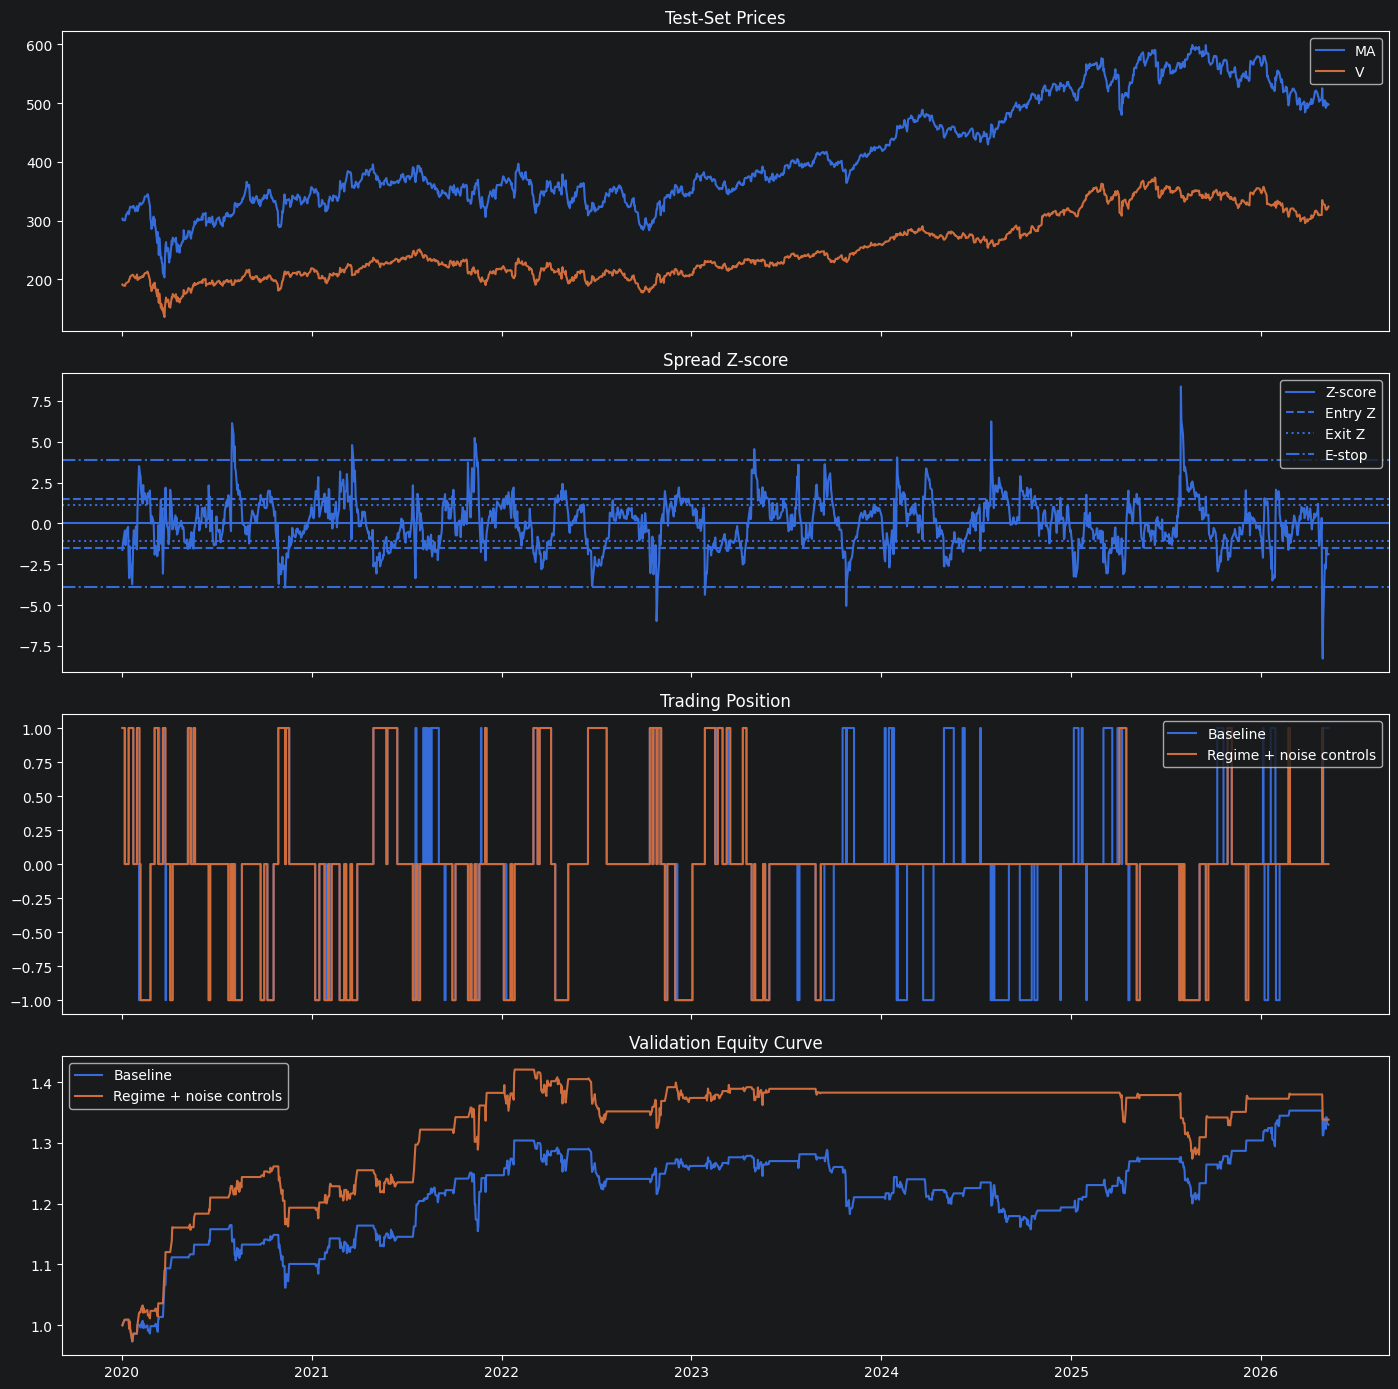

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["MA"], label="MA")
axes[0].plot(validation_df["Date"], validation_df["V"], label="V")
axes[0].set_title("Test-Set Prices")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["zscore"], label="Z-score")
axes[1].axhline(ENTRY_Z, linestyle="--", label="Entry Z")
axes[1].axhline(-ENTRY_Z, linestyle="--")
axes[1].axhline(EXIT_Z, linestyle=":", label="Exit Z")
axes[1].axhline(-EXIT_Z, linestyle=":")
axes[1].axhline(E_STOP, linestyle="-.", label="E-stop")
axes[1].axhline(-E_STOP, linestyle="-.")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("Spread Z-score")
axes[1].legend()

axes[2].step(baseline_df["Date"], baseline_df["position"], where="post", label="Baseline")
axes[2].step(validation_df["Date"], validation_df["position"], where="post", label="Regime + noise controls")
axes[2].set_title("Trading Position")
axes[2].legend()

axes[3].plot(baseline_df["Date"], baseline_df["equity_curve"], label="Baseline")
axes[3].plot(validation_df["Date"], validation_df["equity_curve"], label="Regime + noise controls")
axes[3].set_title("Validation Equity Curve")
axes[3].legend()

plt.tight_layout()
plt.show()


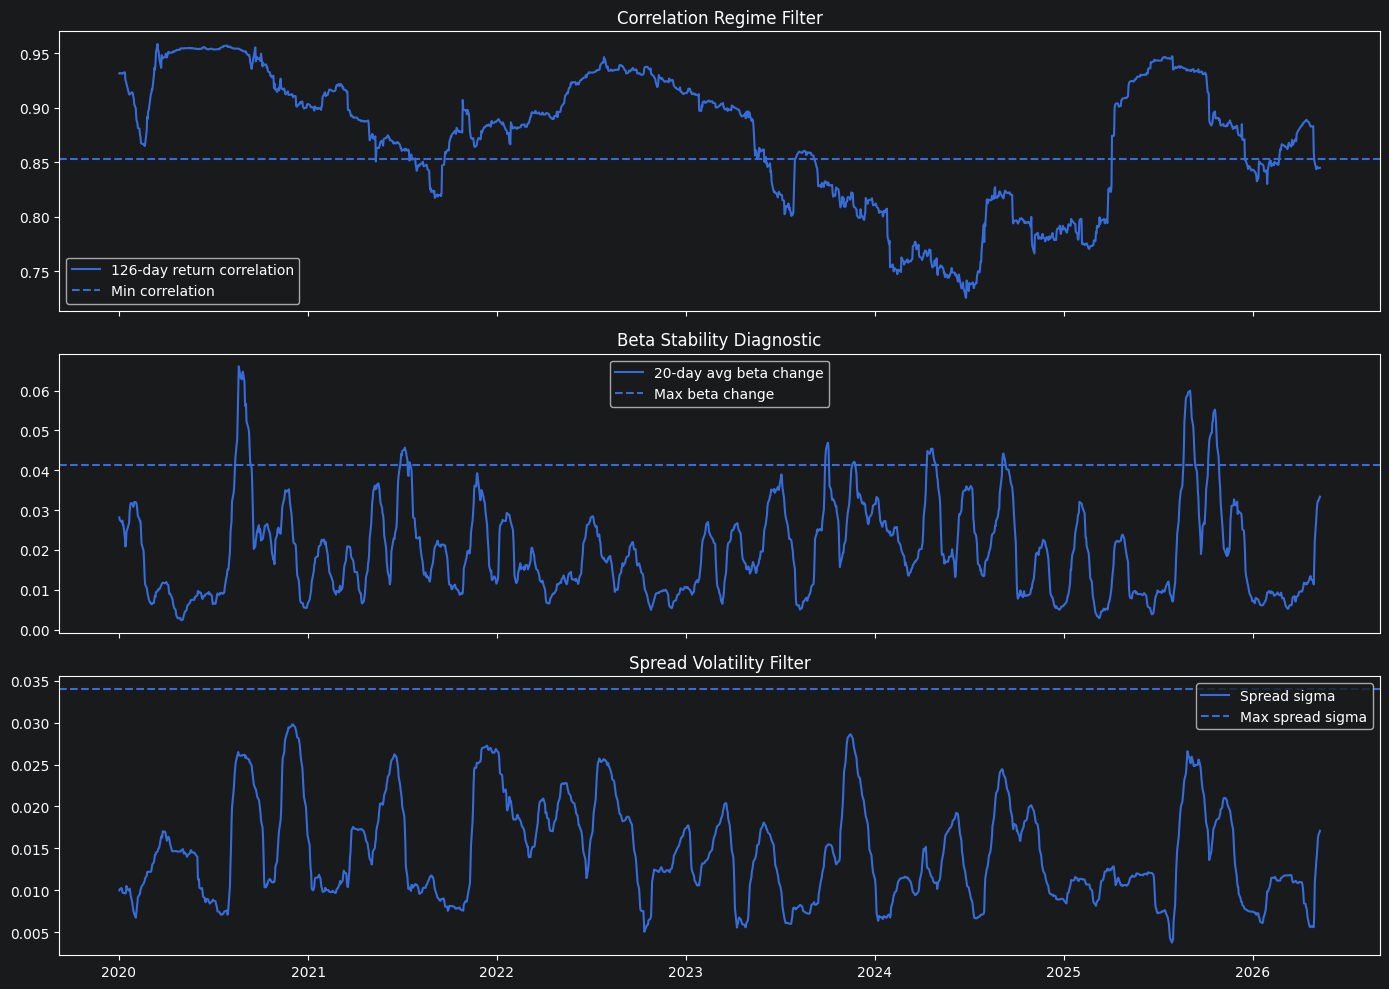

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["return_corr"], label="126-day return correlation")
axes[0].axhline(regime_thresholds["min_corr"], linestyle="--", label="Min correlation")
axes[0].set_title("Correlation Regime Filter")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["beta_change_avg"], label="20-day avg beta change")
axes[1].axhline(regime_thresholds["max_beta_change"], linestyle="--", label="Max beta change")
axes[1].set_title("Beta Stability Diagnostic")
axes[1].legend()

axes[2].plot(validation_df["Date"], validation_df["spread_sigma"], label="Spread sigma")
axes[2].axhline(regime_thresholds["max_spread_sigma"], linestyle="--", label="Max spread sigma")
axes[2].set_title("Spread Volatility Filter")
axes[2].legend()

plt.tight_layout()
plt.show()
